In [2]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]/2 [kagglehub]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 8.42M/8.42M [00:57<00:00, 153kB/s] 

Extracting files...
Path to dataset files: /Users/rafael/.cache/kagglehub/datasets/yashdev01/spotify-tracks-dataset/versions/1


In [17]:
import pandas as pd
df_spotify = pd.read_csv(path+'/spotify-tracks-dataset.csv')

In [15]:
import pandas as pd
import numpy as np



# Artist Metadata for Merging (Problem 5)
artist_metadata = pd.DataFrame({
    'artist_name': ['Taylor Swift', 'Drake', 'Bad Bunny', 'BTS', 'Arctic Monkeys'],
    'global_region': ['North America', 'North America', 'Latin America', 'Asia', 'Europe'],
    'is_independent': [False, False, False, False, True]
})

## Problem 1 

 Genre Filter & Popularity / Ժանրերի զտում և հանրաճանաչությունEnglish: We need to find the "hits." Filter the dataset to find all tracks in the 'pop' or 'rock' genres that have a popularity score of 80 or higher. Sort the results so the most popular track is at the top.Հայերեն: Մենք պետք է գտնենք «հիթերը»։ Զտեք տվյալների բազան՝ գտնելու 'pop' կամ 'rock' ժանրերի բոլոր այն երգերը, որոնց հանրաճանաչության (popularity) միավորը 80 կամ ավելի բարձր է։ Դասավորեք արդյունքներն այնպես, որ ամենահանրաճանաչ երգը լինի վերևում։


## Problem 2 

 Audio Feature Aggregation / Աուդիո բնութագրերի ամփոփումEnglish: Which genre is the most "energetic"? Create a summary table showing the Average Energy and Average Acousticness for every track_genre. Which genre has the highest average energy?Հայերեն: Ո՞ր ժանրն է ամենաէներգիկը։ Ստեղծեք ամփոփիչ աղյուսակ, որը ցույց կտա Միջին էներգիան (Energy) և Միջին ակուստիկությունը (Acousticness) յուրաքանչյուր track_genre-ի համար։ Ո՞ր ժանրն ունի ամենաբարձր միջին էներգիան։


## Problem 3 

 The "Vibe Check" Column / «Տրամադրության ստուգման» սյունակEnglish: 1. Create a new column called vibe_score using the following formula:$$vibe\_score = (danceability + valence) \times energy$$2. Identify tracks that are "Explicit" and have a vibe_score greater than 1.5. Show only the track_name, artists, and vibe_score.Հայերեն: 1. Ստեղծեք նոր սյունակ vibe_score անունով՝ հետևյալ բանաձևով.$$vibe\_score = (danceability + valence) \times energy$$2. Բացահայտեք այն երգերը, որոնք պարունակում են ոչ նորմատիվային բառապաշար (explicit) և ունեն 1.5-ից բարձր vibe_score: Ցուցադրեք միայն track_name, artists և vibe_score սյունակները։


## Problem 4

 Key & Mode Pivot Table / Տոնայնության և մոդուսի ամփոփիչ աղյուսակEnglish: Music theorists want to know how key and mode affect popularity. Create a Pivot Table where the rows are the key (0-11) and the columns are the mode (0 for Minor, 1 for Major). For the values, calculate the Average Popularity and add margins=True to see total averages.Հայերեն: Երաժշտության տեսաբանները ցանկանում են իմանալ, թե ինչպես են տոնայնությունը (key) և մոդուսը (mode) ազդում հանրաճանաչության վրա։ Ստեղծեք ամփոփիչ աղյուսակ (Pivot Table), որտեղ տողերը կլինեն տոնայնությունները (0-11), իսկ սյունակները՝ մոդուսը (0՝ մինորի համար, 1՝ մաժորի համար)։ Արժեքների համար հաշվարկեք Միջին հանրաճանաչությունը և ավելացրեք margins=True ընդհանուր միջինները տեսնելու համար։


## Problem 5  

Global Artist Analysis / Համաշխարհային արտիստների վերլուծությունEnglish: 1. Merge the df_spotify table with the artist_metadata provided in the setup (link artists to artist_name).2. Filter for tracks where the artist is identified as "Independent" (is_independent == True).3. For these independent artists, create a pivot table showing the Total Number of Tracks and the Average Tempo per global_region.Հայերեն: 1. Միավորեք (merge) df_spotify աղյուսակը setup-ում տրված artist_metadata աղյուսակի հետ (կապեք artists-ը artist_name-ի հետ)։2. Զտեք այն երգերը, որտեղ արտիստը նշված է որպես «Անկախ» (is_independent == True):3. Այս անկախ արտիստների համար ստեղծեք ամփոփիչ աղյուսակ, որը ցույց կտա Երգերի ընդհանուր քանակը և Միջին տեմպը (tempo) ըստ global_region-ի (աշխարհագրական տարածաշրջանի)։

In [21]:
# --- Problem 1: Genre Filter ---
genres = ['pop', 'rock']
ans_1 = df_spotify[(df_spotify['track_genre'].isin(genres)) & (df_spotify['popularity'] >= 80)]
ans_1 = ans_1.sort_values(by='popularity', ascending=False)
ans_1

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,vibe_score
81051,81051,81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,...,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,pop,0.449344
81210,81210,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,...,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop,0.834725
91003,91003,91003,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,...,1,0.0475,0.08260,0.000745,0.0546,0.825,139.994,4,rock,1.218613
81003,81003,81003,5IgjP7X4th6nMNDh4akUHb,Chris Brown,Indigo (Extended),Under The Influence,96,184613,True,0.733,...,0,0.0427,0.06350,0.000001,0.1050,0.310,116.992,4,pop,0.719670
81174,81174,81174,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,...,1,0.0475,0.08260,0.000745,0.0546,0.825,139.994,4,pop,1.218613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91500,91500,91500,2xql0pid3EUwW38AsywxhV,The Neighbourhood,Hard To Imagine The Neighbourhood Ever Changing,Reflections,80,244013,False,0.648,...,0,0.0293,0.11400,0.046200,0.1160,0.544,113.983,4,rock,0.708048
81870,81870,81870,3zkWCteF82vJwv0hRLba76,Shawn Mendes,Handwritten,Stitches,80,206880,False,0.746,...,1,0.0676,0.01520,0.000000,0.0486,0.746,149.882,4,pop,1.124968
81364,81364,81364,2Bs4jQEGMycglOfWPBqrVG,One Direction,FOUR (Deluxe),Steal My Girl,80,228133,False,0.536,...,0,0.0347,0.00433,0.000000,0.1140,0.545,77.217,4,pop,0.830208
81831,81831,81831,3XYRV7ZSHqIRDG87DKTtry,BTS,Permission to Dance,Permission to Dance,80,187585,False,0.702,...,1,0.0427,0.00544,0.000000,0.3370,0.646,124.925,4,pop,0.998868


In [29]:
df_spotify.drop_duplicates(subset=['track_id'], inplace=True)

In [30]:
# --- Problem 1: Genre Filter ---
# genres = ['pop', 'rock']
ans_1 = df_spotify[(df_spotify['track_genre'].isin(['pop', 'rock'])) & (df_spotify['popularity'] >= 80)]
ans_1 = ans_1.sort_values(by='popularity', ascending=False)
print(ans_1.shape)
ans_1.drop_duplicates(subset=['track_id'], inplace=True)
print(ans_1.shape)

(92, 23)
(92, 23)


In [31]:
# --- Problem 2: Audio Feature Aggregation ---
genre_summary = df_spotify.groupby('track_genre')[['energy', 'acousticness']].mean()
most_energetic_genre = genre_summary['energy'].idxmax()
most_energetic_genre

'death-metal'

In [33]:
# --- Problem 3: Vibe Check ---
df_spotify['vibe_score'] = (df_spotify['danceability'] + df_spotify['valence']) * df_spotify['energy']
ans_3 = df_spotify[(df_spotify['explicit'] == True) & (df_spotify['vibe_score'] > 1.5)]
ans_3 = ans_3[['track_name', 'artists', 'vibe_score']]
ans_3

,track_name,artists,vibe_score
1100,Atrévete-Te-Te,Calle 13,1.503136
1338,Kinkinzazo,Plastilina Mosh,1.559460
10232,London Sound,Freestylers,1.586880
10372,Superbad,Aquasky,1.526844
20410,Super Freaky Girl,Nicki Minaj,1.659042
20616,Budget,Megan Thee Stallion;Latto,1.576146
20618,Budget,Megan Thee Stallion;Latto,1.576146
20622,Budget,Megan Thee Stallion;Latto,1.576146
20924,Super Freaky Girl,Nicki Minaj,1.645372
21193,Till The End,Elephant Man,1.584913


<Axes: xlabel='key'>

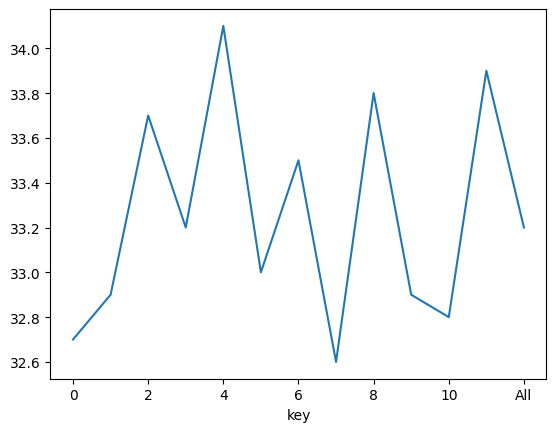

In [39]:
# --- Problem 4: Pivot Table ---
ans_4 = df_spotify.pivot_table(
    index='key', 
    columns='mode', 
    values='popularity', 
    aggfunc='mean', 
    margins=True
)
ans_4.round(1)['All'].plot()

In [44]:
# --- Problem 5: Global Artist Analysis ---
# Note: Cleaning 'artists' string might be needed if they contain multiple names
merged_df = pd.merge(df_spotify, artist_metadata, left_on='artists', right_on='artist_name', how='inner')
independent_df = merged_df[merged_df['is_independent'] == True]
ans_5 = independent_df.pivot_table(
    index='global_region', 
    values=['track_id', 'tempo'], 
    aggfunc={'track_id': 'count', 'tempo': 'mean'}
)
print(independent_df['artist_name'])
ans_5

0      Arctic Monkeys
1      Arctic Monkeys
2      Arctic Monkeys
3      Arctic Monkeys
4      Arctic Monkeys
            ...      
105    Arctic Monkeys
106    Arctic Monkeys
107    Arctic Monkeys
108    Arctic Monkeys
110    Arctic Monkeys
Name: artist_name, Length: 110, dtype: str


,tempo,track_id
global_region,,
Europe,124.2636,110


In [19]:
# --- Problem 1: Genre Filter ---
genres = ['pop', 'rock']
ans_1 = df_spotify[(df_spotify['track_genre'].isin(genres)) & (df_spotify['popularity'] >= 80)]
ans_1 = ans_1.sort_values(by='popularity', ascending=False)

# --- Problem 2: Audio Feature Aggregation ---
genre_summary = df_spotify.groupby('track_genre')[['energy', 'acousticness']].mean()
most_energetic_genre = genre_summary['energy'].idxmax()

# --- Problem 3: Vibe Check ---
df_spotify['vibe_score'] = (df_spotify['danceability'] + df_spotify['valence']) * df_spotify['energy']
ans_3 = df_spotify[(df_spotify['explicit'] == True) & (df_spotify['vibe_score'] > 1.5)]
ans_3 = ans_3[['track_name', 'artists', 'vibe_score']]

# --- Problem 4: Pivot Table ---
ans_4 = df_spotify.pivot_table(
    index='key', 
    columns='mode', 
    values='popularity', 
    aggfunc='mean', 
    margins=True
)

# --- Problem 5: Global Artist Analysis ---
# Note: Cleaning 'artists' string might be needed if they contain multiple names
merged_df = pd.merge(df_spotify, artist_metadata, left_on='artists', right_on='artist_name', how='inner')
independent_df = merged_df[merged_df['is_independent'] == True]
ans_5 = independent_df.pivot_table(
    index='global_region', 
    values=['track_id', 'tempo'], 
    aggfunc={'track_id': 'count', 'tempo': 'mean'}
)